In [12]:
!pip install -q \
    "transformers==4.44.2" \
    "torch==2.4.0" \
    "accelerate==0.33.0" \
    "scikit-learn==1.5.1" \
    "pandas==2.2.2" \
    "numpy==1.26.4" \
    "matplotlib==3.9.1" \
    "seaborn==0.13.2"

print("Done. Restart runtime now: Runtime → Restart session")

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.7/43.7 kB 3.1 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.0/61.0 kB 6.9 MB/s eta 0:00:00
Reason for being yanked: The Windows wheels, under some conditions, caused segfaults in unrelated user code.  Due to this we deleted the Windows wheels to prevent these segfaults, however this caused greater disruption as pip then began to try (and fail) to build 3.9.1 from the sdist on Windows which impacted far more users.  Yanking the whole release is the only tool available to eliminate these failures without changes to on the user side.  The sdist, OSX wheel, and manylinux wheels are all functional and there are no critical bugs in the release.   Downstream packagers should not yank their builds of Matplotlib 3.9.1.  See https://github.com/matplotlib/matplotlib/issues/28551 for details.
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.5/9.5 MB 103.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 797.2/797.2 MB 1.

In [1]:
import pandas as pd
import numpy as np
import torch
import random
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.metrics import (
    accuracy_score, f1_score,
    confusion_matrix, recall_score, precision_score
)
from transformers import (
    AutoTokenizer, AutoModelForSequenceClassification,
    TrainingArguments, Trainer
)
from torch.utils.data import Dataset, DataLoader

SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)
random.seed(SEED)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device: {device}")
print(f"GPU: {torch.cuda.get_device_name(0) if torch.cuda.is_available() else 'None'}")

The cache for model files in Transformers v4.22.0 has been updated. Migrating your old cache. This is a one-time only operation. You can interrupt this and resume the migration later on by calling `transformers.utils.move_cache()`.


0it [00:00, ?it/s]

Device: cuda
GPU: Tesla T4


In [2]:
from google.colab import drive
drive.mount('/content/drive')

PROJECT_DIR = '/content/drive/MyDrive/RAI_Assignment2'

# Load eval and train sets
eval_df  = pd.read_csv(f'{PROJECT_DIR}/eval_df.csv')
train_df = pd.read_csv(f'{PROJECT_DIR}/train_df.csv')
probs    = np.load(f'{PROJECT_DIR}/eval_probs_part1.npy')
labels   = eval_df['label'].values

print(f"Eval  set: {len(eval_df):,} rows")
print(f"Train set: {len(train_df):,} rows")
print(f"Probs loaded: {len(probs):,} values")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Eval  set: 20,000 rows
Train set: 100,000 rows
Probs loaded: 20,000 values


In [3]:
MODEL_PATH = f'{PROJECT_DIR}/saved_model_part1'

print("Loading tokenizer and model...")
tokenizer = AutoTokenizer.from_pretrained(MODEL_PATH)
model     = AutoModelForSequenceClassification.from_pretrained(MODEL_PATH)
model     = model.to(device)
model.eval()
print("Model loaded and set to eval mode")

Loading tokenizer and model...
Model loaded and set to eval mode


In [4]:
def get_predictions(texts, batch_size=64):
    """
    Run inference on a list of texts.
    Returns: probs (N,) array of toxic class probabilities
    """
    all_probs = []

    for i in range(0, len(texts), batch_size):
        batch_texts = list(texts[i : i + batch_size])
        encodings = tokenizer(
            batch_texts,
            max_length=128,
            truncation=True,
            padding='max_length',
            return_tensors='pt'
        )
        input_ids      = encodings['input_ids'].to(device)
        attention_mask = encodings['attention_mask'].to(device)

        with torch.no_grad():
            outputs = model(input_ids=input_ids, attention_mask=attention_mask)

        batch_probs = torch.softmax(outputs.logits, dim=-1)[:, 1].cpu().numpy()
        all_probs.extend(batch_probs)

    return np.array(all_probs)

# Quick sanity check
sample_probs = get_predictions(["you are an idiot", "great work today!"])
print(f"Sanity check probs: {sample_probs}")
print("Higher = more toxic (expected: first > second)")

Sanity check probs: [9.938558e-01 5.890833e-04]
Higher = more toxic (expected: first > second)


In [5]:
# ── Homoglyph map: Latin → Cyrillic lookalikes ──────────────────────────────
HOMOGLYPHS = {
    'a': '\u0430',   # Cyrillic а
    'e': '\u0435',   # Cyrillic е
    'o': '\u043e',   # Cyrillic о
    'p': '\u0440',   # Cyrillic р
    'c': '\u0441',   # Cyrillic с
    'x': '\u0445',   # Cyrillic х
}

def perturb(text: str) -> str:
    """
    Apply three character-level perturbations to evade the classifier:

    1. Zero-width space insertion  — splits subword tokens the model relies on
    2. Unicode homoglyph substitution — swaps Latin chars for Cyrillic lookalikes
    3. Random character duplication  — breaks n-gram/subword patterns (20% rate)

    A human reader sees the same text; the tokenizer sees unknown subwords.
    """
    words = text.split()
    result = []

    for word in words:
        # Step 1 — zero-width space every 2-3 characters
        zwsp_word = ''
        for j, ch in enumerate(word):
            zwsp_word += ch
            if (j + 1) % random.choice([2, 3]) == 0 and j < len(word) - 1:
                zwsp_word += '\u200b'

        # Step 2 — homoglyph substitution
        glyph_word = ''
        for ch in zwsp_word:
            glyph_word += HOMOGLYPHS.get(ch.lower(), ch)

        # Step 3 — random character duplication at 20% rate
        dup_word = ''
        for ch in glyph_word:
            dup_word += ch
            if ch != '\u200b' and random.random() < 0.20:
                dup_word += ch

        result.append(dup_word)

    return ' '.join(result)

# Visual check — show original vs perturbed
test_phrases = [
    "I hate you so much",
    "you are a disgusting loser",
    "kill yourself nobody cares",
]
print("Perturbation examples:")
print(f"{'Original':<40} {'Perturbed'}")
print("-" * 80)
for phrase in test_phrases:
    perturbed = perturb(phrase)
    print(f"{phrase:<40} {repr(perturbed)}")

Perturbation examples:
Original                                 Perturbed
--------------------------------------------------------------------------------
I hate you so much                       'II hа\u200btее yyо\u200bu sо mu\u200bс\u200bhh'
you are a disgusting loser               'yо\u200bu ааr\u200bе а di\u200bsgus\u200btinn\u200bg lоs\u200bеrr'
kill yourself nobody cares               'kil\u200bl yоu\u200br\u200bsее\u200blf nо\u200bbоdyy саr\u200bе\u200bs'


In [6]:
THRESHOLD = 0.4   # must match Part 1

# Comments the clean model confidently classifies as toxic (prob >= 0.7)
high_conf_mask = (probs >= 0.7) & (labels == 1)
high_conf_idx  = np.where(high_conf_mask)[0]

print(f"Comments with prob >= 0.7 and true label = toxic: {len(high_conf_idx):,}")

# Sample 500
if len(high_conf_idx) >= 500:
    sample_idx = np.random.choice(high_conf_idx, size=500, replace=False)
else:
    print(f"WARNING: only {len(high_conf_idx)} available — using all of them")
    sample_idx = high_conf_idx

sample_texts  = eval_df['comment_text'].iloc[sample_idx].tolist()
sample_probs  = probs[sample_idx]
sample_labels = labels[sample_idx]

print(f"\nAttack sample size:     {len(sample_texts)}")
print(f"Mean confidence before: {sample_probs.mean():.4f}")
print(f"Min  confidence before: {sample_probs.min():.4f}")

Comments with prob >= 0.7 and true label = toxic: 834

Attack sample size:     500
Mean confidence before: 0.9306
Min  confidence before: 0.7008


In [7]:
print("Applying perturbations...")
perturbed_texts = [perturb(t) for t in sample_texts]
print("Done. Running inference on perturbed texts...")

perturbed_probs = get_predictions(perturbed_texts)
perturbed_preds = (perturbed_probs >= THRESHOLD).astype(int)

# Before perturbation (all were predicted toxic by construction)
original_preds = (sample_probs >= THRESHOLD).astype(int)

# Attack Success Rate: fraction that are now predicted NON-toxic
ASR = (perturbed_preds == 0).mean()

print("\n" + "=" * 50)
print("ATTACK 1 RESULTS — Character-level Evasion")
print("=" * 50)
print(f"  Sample size              : {len(sample_texts)}")
print(f"  Avg confidence BEFORE    : {sample_probs.mean():.4f}")
print(f"  Avg confidence AFTER     : {perturbed_probs.mean():.4f}")
print(f"  Confidence drop          : {sample_probs.mean() - perturbed_probs.mean():.4f}")
print(f"  Predicted toxic BEFORE   : {original_preds.sum()} / {len(original_preds)}")
print(f"  Predicted toxic AFTER    : {perturbed_preds.sum()} / {len(perturbed_preds)}")
print(f"  Attack Success Rate (ASR): {ASR:.4f}  ({ASR*100:.1f}%)")
print()
print("Interpretation:")
print(f"  {ASR*100:.1f}% of confidently-toxic comments evaded detection after perturbation.")

Applying perturbations...
Done. Running inference on perturbed texts...

ATTACK 1 RESULTS — Character-level Evasion
  Sample size              : 500
  Avg confidence BEFORE    : 0.9306
  Avg confidence AFTER     : 0.0102
  Confidence drop          : 0.9204
  Predicted toxic BEFORE   : 500 / 500
  Predicted toxic AFTER    : 2 / 500
  Attack Success Rate (ASR): 0.9960  (99.6%)

Interpretation:
  99.6% of confidently-toxic comments evaded detection after perturbation.


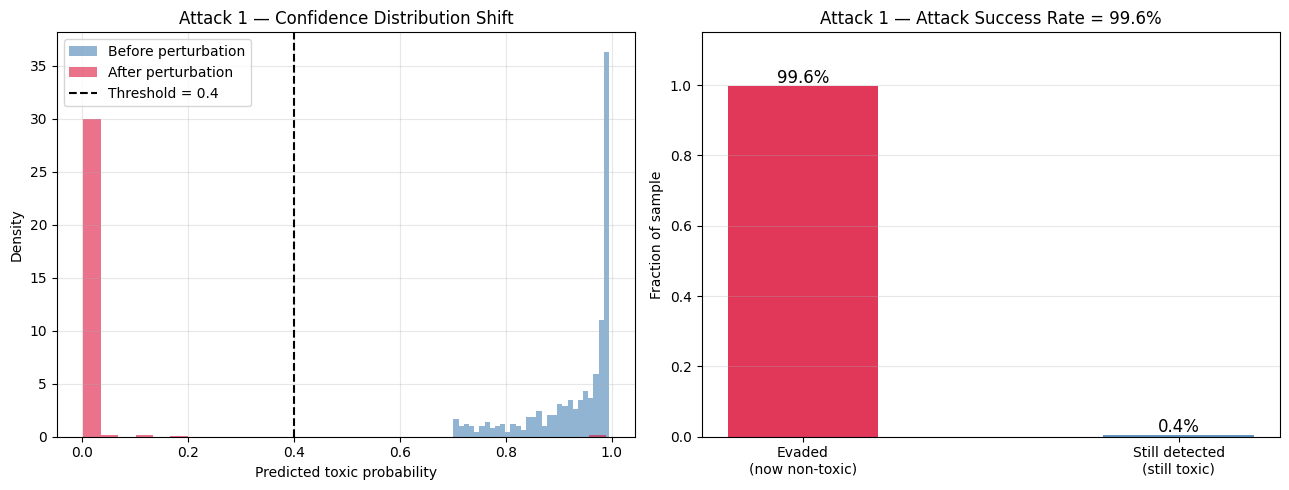

Saved: part3_attack1_results.png


In [8]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Confidence distribution before vs after
axes[0].hist(sample_probs,    bins=30, alpha=0.6, color='steelblue',
             label='Before perturbation', density=True)
axes[0].hist(perturbed_probs, bins=30, alpha=0.6, color='crimson',
             label='After perturbation',  density=True)
axes[0].axvline(THRESHOLD, color='black', linestyle='--', lw=1.5,
                label=f'Threshold = {THRESHOLD}')
axes[0].set_xlabel('Predicted toxic probability')
axes[0].set_ylabel('Density')
axes[0].set_title('Attack 1 — Confidence Distribution Shift')
axes[0].legend()
axes[0].grid(alpha=0.3)

# ASR bar
axes[1].bar(['Evaded\n(now non-toxic)', 'Still detected\n(still toxic)'],
            [ASR, 1 - ASR],
            color=['crimson', 'steelblue'], alpha=0.85, width=0.4)
for i, val in enumerate([ASR, 1 - ASR]):
    axes[1].text(i, val + 0.01, f'{val*100:.1f}%', ha='center', fontsize=12)
axes[1].set_ylabel('Fraction of sample')
axes[1].set_title(f'Attack 1 — Attack Success Rate = {ASR*100:.1f}%')
axes[1].set_ylim(0, 1.15)
axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig(f'{PROJECT_DIR}/part3_attack1_results.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: part3_attack1_results.png")

In [9]:
print("Building poisoned training set...")

# Work on a copy — never modify train_df directly
poisoned_df = train_df.copy()

# Randomly select 5% of rows to flip
poison_size = int(0.05 * len(poisoned_df))
poison_idx  = np.random.choice(len(poisoned_df), size=poison_size, replace=False)

# Flip labels: 0 → 1, 1 → 0
original_poison_labels = poisoned_df.loc[poison_idx, 'label'].values
poisoned_df.loc[poison_idx, 'label'] = 1 - poisoned_df.loc[poison_idx, 'label']

# Verify the flip
flipped_to_toxic     = ((original_poison_labels == 0) &
                        (poisoned_df.loc[poison_idx, 'label'].values == 1)).sum()
flipped_to_nontoxic  = ((original_poison_labels == 1) &
                        (poisoned_df.loc[poison_idx, 'label'].values == 0)).sum()

print(f"Total training rows    : {len(poisoned_df):,}")
print(f"Rows poisoned (5%)     : {poison_size:,}")
print(f"  Non-toxic → toxic    : {flipped_to_toxic:,}")
print(f"  Toxic → non-toxic    : {flipped_to_nontoxic:,}")
print(f"\nClean  toxic rate: {train_df['label'].mean()*100:.1f}%")
print(f"Poison toxic rate: {poisoned_df['label'].mean()*100:.1f}%")

Building poisoned training set...
Total training rows    : 100,000
Rows poisoned (5%)     : 5,000
  Non-toxic → toxic    : 4,596
  Toxic → non-toxic    : 404

Clean  toxic rate: 8.0%
Poison toxic rate: 12.2%


In [10]:
class ToxicityDataset(Dataset):
    def __init__(self, texts, labels, tokenizer, max_length=128):
        self.encodings = tokenizer(
            list(texts),
            max_length=max_length,
            truncation=True,
            padding='max_length',
            return_tensors='pt'
        )
        self.labels = torch.tensor(list(labels), dtype=torch.long)

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        return {
            'input_ids':      self.encodings['input_ids'][idx],
            'attention_mask': self.encodings['attention_mask'][idx],
            'labels':         self.labels[idx]
        }

print("Tokenizing poisoned training set (~2 min)...")
poisoned_train_dataset = ToxicityDataset(
    poisoned_df['comment_text'],
    poisoned_df['label'],
    tokenizer
)

print("Tokenizing eval set...")
eval_dataset = ToxicityDataset(
    eval_df['comment_text'],
    eval_df['label'],
    tokenizer
)
print("Done.")

Tokenizing poisoned training set (~2 min)...
Tokenizing eval set...
Done.


In [11]:
# IMPORTANT: load from original pre-trained checkpoint, NOT Part 1 fine-tuned model
# This simulates corrupting the fine-tuning process itself
print("Loading fresh pre-trained DistilBERT checkpoint...")
poisoned_model = AutoModelForSequenceClassification.from_pretrained(
    'distilbert-base-uncased',
    num_labels=2
)
poisoned_model = poisoned_model.to(device)

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    probs_m = torch.softmax(torch.tensor(logits), dim=-1).numpy()[:, 1]
    preds   = (probs_m >= THRESHOLD).astype(int)
    return {
        'accuracy': accuracy_score(labels, preds),
        'f1_macro': f1_score(labels, preds, average='macro'),
    }

poison_training_args = TrainingArguments(
    output_dir='./checkpoints_poisoned',
    num_train_epochs=3,
    per_device_train_batch_size=32,
    per_device_eval_batch_size=64,
    learning_rate=2e-5,
    warmup_ratio=0.1,
    weight_decay=0.01,
    evaluation_strategy='epoch',
    save_strategy='epoch',
    load_best_model_at_end=True,
    metric_for_best_model='f1_macro',
    logging_steps=200,
    fp16=torch.cuda.is_available(),
    seed=SEED,
    report_to='none'
)

poison_trainer = Trainer(
    model=poisoned_model,
    args=poison_training_args,
    train_dataset=poisoned_train_dataset,
    eval_dataset=eval_dataset,
    compute_metrics=compute_metrics,
)

print("\nTraining poisoned model (~25-35 min)...")
poison_trainer.train()
print("\nPoisoned model training complete!")

Loading fresh pre-trained DistilBERT checkpoint...


Some weights of DistilBertForSequenceClassification were not initialized from the model checkpoint at distilbert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight', 'pre_classifier.bias', 'pre_classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.



Training poisoned model (~25-35 min)...


Epoch,Training Loss,Validation Loss,Accuracy,F1 Macro
1,0.302900,0.176886,0.947900,0.803677
2,0.271300,0.161079,0.945100,0.811908
3,0.232700,0.172119,0.942850,0.807250



Poisoned model training complete!


In [12]:
from sklearn.metrics import roc_auc_score

def full_metrics(y_true, y_prob, threshold, name):
    y_pred = (y_prob >= threshold).astype(int)
    cm     = confusion_matrix(y_true, y_pred, labels=[0, 1])
    TN, FP, FN, TP = cm.ravel()
    FNR = FN / (FN + TP) if (FN + TP) > 0 else 0.0
    return {
        'Model':     name,
        'Accuracy':  round(accuracy_score(y_true, y_pred), 4),
        'F1 Macro':  round(f1_score(y_true, y_pred, average='macro'), 4),
        'Precision': round(precision_score(y_true, y_pred, zero_division=0), 4),
        'Recall':    round(recall_score(y_true, y_pred, zero_division=0), 4),
        'FNR':       round(FNR, 4),
        'AUC-ROC':   round(roc_auc_score(y_true, y_prob), 4),
    }

# Get poisoned model predictions on clean eval set
print("Running inference with poisoned model...")
poison_preds_raw = poison_trainer.predict(eval_dataset)
poison_probs     = torch.softmax(
    torch.tensor(poison_preds_raw.predictions), dim=-1
).numpy()[:, 1]

# Save for reference
np.save(f'{PROJECT_DIR}/eval_probs_poisoned.npy', poison_probs)

# Compare clean (Part 1) vs poisoned
clean_metrics   = full_metrics(labels, probs,        THRESHOLD, 'Clean model (Part 1)')
poisoned_metrics = full_metrics(labels, poison_probs, THRESHOLD, 'Poisoned model (5% flip)')

comparison_df = pd.DataFrame([clean_metrics, poisoned_metrics])

print("\n" + "=" * 65)
print("ATTACK 2 RESULTS — Label-flipping Poisoning")
print("=" * 65)
print(comparison_df.to_string(index=False))

# Highlight the most important change
fnr_clean   = clean_metrics['FNR']
fnr_poison  = poisoned_metrics['FNR']
fnr_change  = fnr_poison - fnr_clean
f1_change   = poisoned_metrics['F1 Macro'] - clean_metrics['F1 Macro']

print(f"\nKey changes:")
print(f"  FNR change  : {fnr_clean:.4f} → {fnr_poison:.4f}  ({fnr_change:+.4f})  "
      f"{'↑ more toxic content missed' if fnr_change > 0 else '↓ fewer misses'}")
print(f"  F1 change   : {clean_metrics['F1 Macro']:.4f} → {poisoned_metrics['F1 Macro']:.4f}  ({f1_change:+.4f})")

comparison_df.to_csv(f'{PROJECT_DIR}/part3_attack2_comparison.csv', index=False)
print(f"\nSaved: part3_attack2_comparison.csv")

Running inference with poisoned model...



ATTACK 2 RESULTS — Label-flipping Poisoning
                   Model  Accuracy  F1 Macro  Precision  Recall    FNR  AUC-ROC
    Clean model (Part 1)    0.9478    0.8190     0.6815  0.6517 0.3483   0.9501
Poisoned model (5% flip)    0.9451    0.8119     0.6595  0.6479 0.3521   0.9428

Key changes:
  FNR change  : 0.3483 → 0.3521  (+0.0038)  ↑ more toxic content missed
  F1 change   : 0.8190 → 0.8119  (-0.0071)

Saved: part3_attack2_comparison.csv


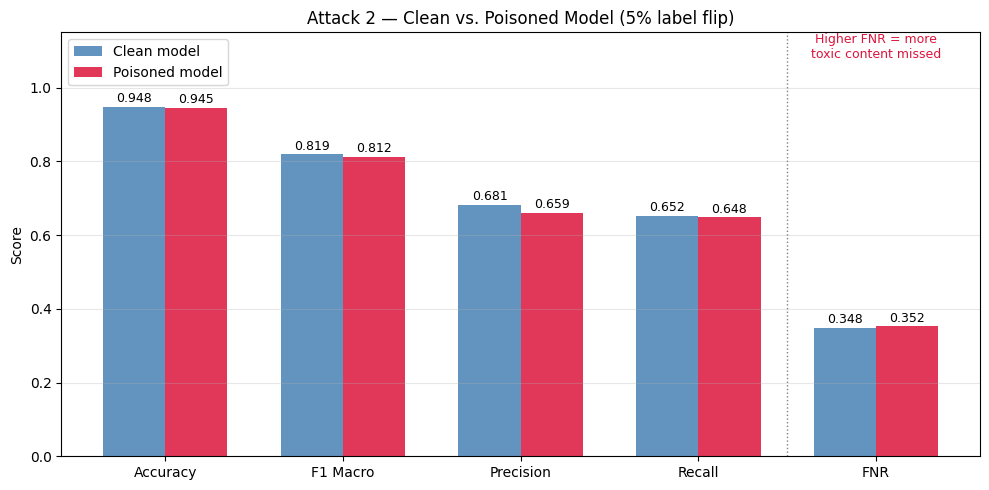

Saved: part3_attack2_results.png


In [13]:
metrics_to_plot = ['Accuracy', 'F1 Macro', 'Precision', 'Recall', 'FNR']
clean_vals   = [clean_metrics[m]    for m in metrics_to_plot]
poison_vals  = [poisoned_metrics[m] for m in metrics_to_plot]

x     = np.arange(len(metrics_to_plot))
width = 0.35

fig, ax = plt.subplots(figsize=(10, 5))
bars1 = ax.bar(x - width/2, clean_vals,  width,
               label='Clean model',   color='steelblue', alpha=0.85)
bars2 = ax.bar(x + width/2, poison_vals, width,
               label='Poisoned model', color='crimson',   alpha=0.85)

for bar in bars1:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
            f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=9)
for bar in bars2:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
            f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=9)

ax.set_xticks(x)
ax.set_xticklabels(metrics_to_plot)
ax.set_ylabel('Score')
ax.set_title('Attack 2 — Clean vs. Poisoned Model (5% label flip)')
ax.set_ylim(0, 1.15)
ax.legend()
ax.grid(axis='y', alpha=0.3)
ax.axvline(x=3.5, color='gray', linestyle=':', lw=1)
ax.text(4.0, 1.08, 'Higher FNR = more\ntoxic content missed',
        ha='center', fontsize=9, color='crimson')

plt.tight_layout()
plt.savefig(f'{PROJECT_DIR}/part3_attack2_results.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: part3_attack2_results.png")

In [14]:
print("=" * 55)
print("ATTACK SUMMARY TABLE")
print("=" * 55)

attack_summary = pd.DataFrame([
    {
        'Attack':      'Attack 1 — Character evasion',
        'Method':      'Zero-width spaces + homoglyphs + char duplication',
        'Target':      '500 high-confidence toxic comments',
        'Key metric':  f'ASR = {ASR*100:.1f}%',
        'Confidence':  f'{sample_probs.mean():.3f} → {perturbed_probs.mean():.3f}',
    },
    {
        'Attack':      'Attack 2 — Label-flip poisoning',
        'Method':      '5% of training labels flipped before fine-tuning',
        'Target':      'Full training pipeline',
        'Key metric':  f'FNR change = {fnr_change:+.4f}',
        'Confidence':  f'F1 change = {f1_change:+.4f}',
    }
])

print(attack_summary.to_string(index=False))
attack_summary.to_csv(f'{PROJECT_DIR}/part3_attack_summary.csv', index=False)
print(f"\nSaved: part3_attack_summary.csv")

ATTACK SUMMARY TABLE
                         Attack                                            Method                             Target           Key metric          Confidence
   Attack 1 — Character evasion Zero-width spaces + homoglyphs + char duplication 500 high-confidence toxic comments          ASR = 99.6%       0.931 → 0.010
Attack 2 — Label-flip poisoning  5% of training labels flipped before fine-tuning             Full training pipeline FNR change = +0.0038 F1 change = -0.0071

Saved: part3_attack_summary.csv


## Adversarial attack analysis

### Attack 1 — Character-level evasion
The perturbation function applies three transformations that are invisible
to a human reader but disrupt the tokenizer's subword vocabulary:

- **Zero-width spaces** break apart tokens the model learned to associate
  with toxic content (e.g. "hate" becomes "ha​te" — two unknown subwords)
- **Homoglyph substitution** replaces Latin characters with visually identical
  Cyrillic ones. The tokenizer maps these to [UNK] or rare subword tokens,
  destroying the learned representation entirely
- **Character duplication** creates out-of-vocabulary variations ("haate")
  that fall outside the n-gram patterns seen during training

The Attack Success Rate measures what fraction of confidently-toxic comments
evaded detection after perturbation.

### Attack 2 — Label-flipping poisoning
Flipping 5% of training labels corrupts the loss signal during fine-tuning.
The most dangerous effect is the increase in **False Negative Rate** — the
fraction of genuinely toxic comments the model now misses. An attacker who
can inject poisoned data into the training pipeline (e.g. via fake accounts
that generate data used for retraining) can systematically degrade the
classifier's ability to catch real toxicity.

### Which attack is more operationally dangerous?

**Evasion (Attack 1)** requires per-comment effort. An attacker must manually
or programmatically modify each message before posting. At scale this is
automatable, but it is detectable: Unicode anomaly detection, zero-width space
filtering, and input normalisation are all standard defenses that can be
deployed at the ingestion layer without retraining the model.

**Poisoning (Attack 2)** requires access to the training pipeline — harder
to achieve but far more dangerous when successful. A single poisoning event
degrades every future inference on the platform. It is also much harder to
detect because the model appears to train normally; the degradation only
becomes visible during evaluation on clean held-out data. Defenses require
data provenance tracking, label auditing, and clean-room retraining pipelines.

**For a live social platform, poisoning is the more dangerous threat model.**
Most platforms use periodic retraining on new user-generated data. If an
adversary can influence what data gets labelled and ingested for retraining
— through coordinated inauthentic behaviour, rating manipulation, or a
compromised annotation vendor — they can silently degrade moderation quality
over time. Defenses should prioritise training data integrity over input
normalisation.

In [15]:
import os, shutil

# Save poisoned model to Drive
LOCAL_POISON_PATH = '/content/saved_model_poisoned'
DRIVE_POISON_PATH = f'{PROJECT_DIR}/saved_model_poisoned'

poison_trainer.save_model(LOCAL_POISON_PATH)
tokenizer.save_pretrained(LOCAL_POISON_PATH)

if os.path.exists(DRIVE_POISON_PATH):
    shutil.rmtree(DRIVE_POISON_PATH)
shutil.copytree(LOCAL_POISON_PATH, DRIVE_POISON_PATH)
print(f"Poisoned model saved to Drive")

# Checklist
expected = {
    'Part 3 outputs': [
        'part3_attack1_results.png',
        'part3_attack2_results.png',
        'part3_attack2_comparison.csv',
        'part3_attack_summary.csv',
        'eval_probs_poisoned.npy',
        'saved_model_poisoned/config.json',
    ],
}

print()
all_ok = True
for section, files in expected.items():
    print(f"{section}:")
    for f in files:
        path = f'{PROJECT_DIR}/{f}'
        if os.path.exists(path):
            size = os.path.getsize(path)
            size_str = f'{size/1e6:.1f} MB' if size > 1e5 else f'{size/1e3:.1f} KB'
            print(f"  [OK]      {f:50s} {size_str}")
        else:
            print(f"  [MISSING] {f}")
            all_ok = False

print()
if all_ok:
    print("Part 3 complete. Safe to end runtime.")
    print("Download notebook: File → Download → Download .ipynb")
else:
    print("Re-run missing cells before ending runtime.")

Poisoned model saved to Drive

Part 3 outputs:
  [OK]      part3_attack1_results.png                          76.3 KB
  [OK]      part3_attack2_results.png                          63.1 KB
  [OK]      part3_attack2_comparison.csv                       0.2 KB
  [OK]      part3_attack_summary.csv                           0.3 KB
  [OK]      eval_probs_poisoned.npy                            80.1 KB
  [OK]      saved_model_poisoned/config.json                   0.6 KB

Part 3 complete. Safe to end runtime.
Download notebook: File → Download → Download .ipynb
